In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('df_clasificacion.csv', index_col=0)
df.head()

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado,nivel_dificultad_Difícil,nivel_dificultad_Fácil,nivel_dificultad_Medio,tiene_tutor_No,tiene_tutor_Sí
0,0.331561,0.269009,0.833002,0.445949,0.636364,0.463128,1.000000,0.777143,1.0,0.0,1.0,0.0,0.0,1.0
1,0.418439,0.726082,0.793121,0.102807,0.000000,0.463128,0.000000,0.600000,1.0,1.0,0.0,0.0,1.0,0.0
2,0.146282,0.862624,0.682795,0.625874,0.636364,0.561063,1.000000,0.714286,1.0,0.0,1.0,0.0,1.0,0.0
3,0.235301,0.741118,0.785623,0.765471,0.454545,1.000000,0.465920,0.688571,1.0,0.0,1.0,0.0,1.0,0.0
4,0.000000,0.517917,0.431749,0.445307,0.272727,1.000000,0.758538,0.514286,1.0,0.0,0.0,1.0,1.0,0.0


Separamos la variable objetivo y dividimos el dataframe.

In [3]:
tv = 'aprobado'

X = df.drop(columns=[tv,'nota_final']) # Quitamos la columna objetivo y la columna nota_final.
y = df[tv]

In [4]:
df['aprobado'].value_counts()

aprobado
1.0    898
0.0    102
Name: count, dtype: int64

Al haber mucha diferencia aplicaremos class_weight.

Dividimos en conjunto de entrenamiento y prueba.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Creamos el modelo y lo entrenamos con el conjunto de entrenamiento.

In [6]:
modelo = LogisticRegression(max_iter=1000, class_weight= 'balanced', random_state=42)

In [7]:
modelo.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

Probamos el modelo.

In [8]:
y_pred = modelo.predict(X_test)

Vemos las probabilidades no solo si aprueba o no

In [9]:
y_prob = modelo.predict_proba(X_test)[:, 1] 

Calculamos y vemos la matriz de confusión.

In [10]:
matriz_confusion = confusion_matrix(y_test, y_pred)

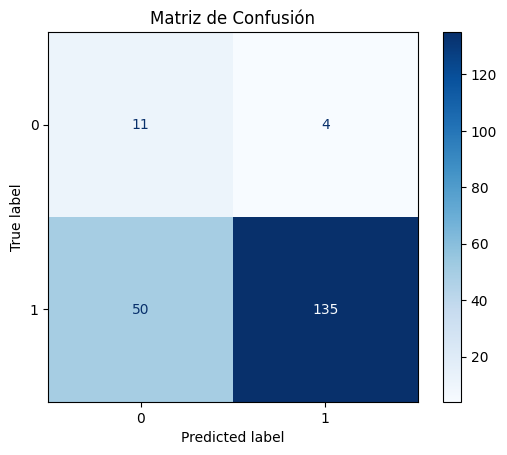

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()

Al aplicar class_weight= 'balanced' vemos que el modelo predice bien los suspensos (solo se escapan 4) pero hay 50 aprobados que predice suspenso.

Probamos sin class_weight= 'balanced'.

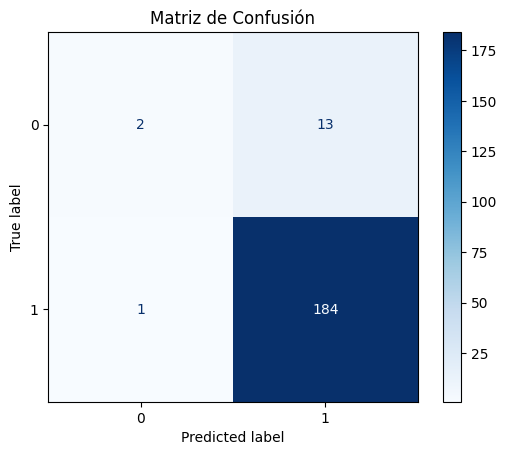

In [12]:
modelo_no_balanced = LogisticRegression(max_iter=1000, random_state=42)
modelo_no_balanced.fit(X_train, y_train)

y_pred_no_balanced = modelo_no_balanced.predict(X_test)

matriz_confusion_2 = confusion_matrix(y_test, y_pred_no_balanced)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_2)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()

Predice perfectamente los aprobados (solo falla en 1) pero de los 15 suspensos solo detecta 2.

Mejor detectar 50 que aprobaran como suspensos que no predecir que todos van a aprobar.

Vamos a calcular las métricas

In [13]:
y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

In [14]:
accuracy_e = accuracy_score (y_train, y_train_pred)
precision_e = precision_score (y_train, y_train_pred)
recall_e = recall_score (y_train, y_train_pred)
f1_e = f1_score (y_train, y_train_pred)

accuracy_t = accuracy_score(y_test, y_test_pred)
precision_t = precision_score(y_test, y_test_pred)
recall_t = recall_score(y_test, y_test_pred)
f1_t = f1_score(y_test, y_test_pred)

In [15]:
df_metricas = pd.DataFrame({
    'Entrenamiento' : [accuracy_e, precision_e, recall_e, f1_e],
    'Prueba' : [accuracy_t, precision_t, recall_t, f1_t]
}, index = ['accuracy', 'precision', 'recall', 'f1_score']).round(2)

df_metricas

,Entrenamiento,Prueba
accuracy,0.74,0.73
precision,0.96,0.97
recall,0.73,0.73
f1_score,0.83,0.83


Vemos que caracteristicas influyen más en la predicción.

In [17]:
coef_df = pd.DataFrame({'Caracteristica': X.columns.to_list(), 'Coeficiente': modelo.coef_[0]})
coef_df = coef_df.sort_values(by='Coeficiente', ascending=False, key=abs)
coef_df

,Caracteristica,Coeficiente
0,horas_estudio_semanal,3.905569
1,nota_anterior,2.358954
2,tasa_asistencia,1.297128
5,horario_estudio_preferido,0.913213
6,estilo_aprendizaje,0.762751
7,nivel_dificultad_Difícil,-0.626156
8,nivel_dificultad_Fácil,0.555937
3,horas_sueno,0.126143
9,nivel_dificultad_Medio,0.072504
4,edad,0.051707


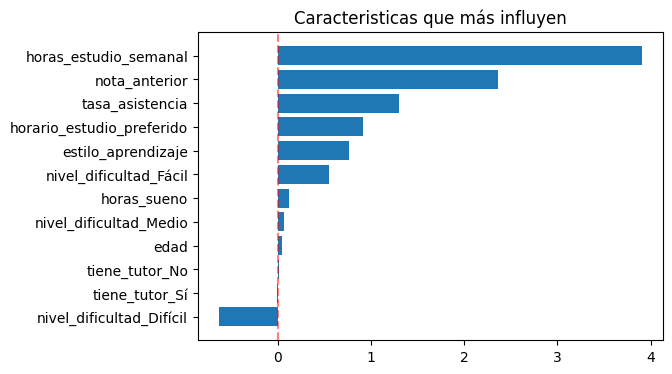

In [18]:
coef_df = coef_df.sort_values(by='Coeficiente') # Lo reordenamos para verlo mejor.
plt.figure(figsize=(6,4))
plt.barh(coef_df['Caracteristica'], coef_df['Coeficiente'])
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.title('Caracteristicas que más influyen')
plt.show()

Entrenamos el modelo con todos los datos y guardamos.

In [19]:
modelo_final = LogisticRegression(max_iter=1000, class_weight= 'balanced', random_state=42)
modelo_final.fit(X, y)


joblib.dump(modelo_final, "modelo_clasificación.pkl")

['modelo_clasificación.pkl']